In [65]:
from __future__ import division
from datetime import datetime, timedelta,date
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
%matplotlib inline

import seaborn as sns

import plotly.offline as pyoff
import plotly.graph_objs as go

import warnings
warnings.filterwarnings("ignore")

In [66]:
df=pd.read_csv("../datasets/sales_prediction_train.csv")

In [67]:
df.tail()

,date,store,item,sales
912995,2017-12-27,10,50,63
912996,2017-12-28,10,50,59
912997,2017-12-29,10,50,74
912998,2017-12-30,10,50,62
912999,2017-12-31,10,50,82


In [68]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 913000 entries, 0 to 912999
Data columns (total 4 columns):
 #   Column  Non-Null Count   Dtype 
---  ------  --------------   ----- 
 0   date    913000 non-null  object
 1   store   913000 non-null  int64 
 2   item    913000 non-null  int64 
 3   sales   913000 non-null  int64 
dtypes: int64(3), object(1)
memory usage: 27.9+ MB


## Data Preprocessing

In [69]:
df['date']=pd.to_datetime(df['date'])

In [70]:
df['date'] = df['date'].dt.year.astype('str') + '-' + df['date'].dt.month.astype('str') + '-01'
df['date'] = pd.to_datetime(df['date'])

In [71]:
df = df.groupby('date').sales.sum().reset_index()

In [72]:
df.head()

,date,sales
0,2013-01-01,454904
1,2013-02-01,459417
2,2013-03-01,617382
3,2013-04-01,682274
4,2013-05-01,763242


## Data Transformation

In [73]:
#plot monthly sales
plot_data = [
    go.Scatter(
        x=df['date'],
        y=df['sales'],
    )
]
plot_layout = go.Layout(
        title='Montly Sales'
    )
fig = go.Figure(data=plot_data, layout=plot_layout)
fig.show()

In [74]:
#creating a new dataframe to model the difference
df_diff=df.copy()
df_diff['prev_sales']=df_diff['sales'].shift(1)

In [75]:
df_diff = df_diff.dropna()
df_diff['diff'] = (df_diff['sales'] - df_diff['prev_sales'])

In [76]:
df_diff.head()

,date,sales,prev_sales,diff
1,2013-02-01,459417,454904.0,4513.0
2,2013-03-01,617382,459417.0,157965.0
3,2013-04-01,682274,617382.0,64892.0
4,2013-05-01,763242,682274.0,80968.0
5,2013-06-01,795597,763242.0,32355.0


In [77]:
#plot monthly sales with sales difference
plot_data = [
    go.Scatter(
        x=df_diff['date'],
        y=df_diff['diff'],
    )
]
plot_layout = go.Layout(
        title='Montly Sales'
    )
fig = go.Figure(data=plot_data, layout=plot_layout)
fig.show()

In [78]:
#We need to use previous monthly sales data to forecast the next ones
#create dataframe for transformation from time series to supervised
df_supervised = df_diff.drop(['prev_sales'],axis=1)
#adding lags
for inc in range(1,13):
    field_name = 'lag_' + str(inc)
    df_supervised[field_name] = df_supervised['diff'].shift(inc)
#drop null values
df_supervised = df_supervised.dropna().reset_index(drop=True)

In [79]:
df_supervised.head()

,date,sales,diff,lag_1,lag_2,lag_3,lag_4,lag_5,lag_6,lag_7,lag_8,lag_9,lag_10,lag_11,lag_12
0,2014-02-01,529117,3130.0,19380.0,-186036.0,36056.0,-33320.0,-76854.0,-89161.0,60325.0,32355.0,80968.0,64892.0,157965.0,4513.0
1,2014-03-01,704301,175184.0,3130.0,19380.0,-186036.0,36056.0,-33320.0,-76854.0,-89161.0,60325.0,32355.0,80968.0,64892.0,157965.0
2,2014-04-01,788914,84613.0,175184.0,3130.0,19380.0,-186036.0,36056.0,-33320.0,-76854.0,-89161.0,60325.0,32355.0,80968.0,64892.0
3,2014-05-01,882877,93963.0,84613.0,175184.0,3130.0,19380.0,-186036.0,36056.0,-33320.0,-76854.0,-89161.0,60325.0,32355.0,80968.0
4,2014-06-01,906842,23965.0,93963.0,84613.0,175184.0,3130.0,19380.0,-186036.0,36056.0,-33320.0,-76854.0,-89161.0,60325.0,32355.0


In [80]:
# Import statsmodels.formula.api
import statsmodels.formula.api as smf
# Define the regression formula
model = smf.ols(formula='diff ~ lag_1', data=df_supervised)
# Fit the regression
model_fit = model.fit()
# Extract the adjusted r-squared
regression_adj_rsq = model_fit.rsquared_adj
print(regression_adj_rsq)

0.02893426930900367


In [81]:
# Import statsmodels.formula.api
import statsmodels.formula.api as smf
# Define the regression formula
model = smf.ols(formula='diff ~ lag_1 + lag_2 + lag_3 + lag_4 + lag_5', data=df_supervised)
# Fit the regression
model_fit = model.fit()
# Extract the adjusted r-squared
regression_adj_rsq = model_fit.rsquared_adj
print(regression_adj_rsq)

0.4406493613886946


In [82]:
# Import statsmodels.formula.api
import statsmodels.formula.api as smf
# Define the regression formula
model = smf.ols(formula='diff ~ lag_1 + lag_2 + lag_3 + lag_4 + lag_5 + lag_6 + lag_7 + lag_8 + lag_9 + lag_10 + lag_11 + lag_12', data=df_supervised)
# Fit the regression
model_fit = model.fit()
# Extract the adjusted r-squared
regression_adj_rsq = model_fit.rsquared_adj
print(regression_adj_rsq)

0.9795722233296558


In [83]:
#import MinMaxScaler and create a new dataframe for LSTM model
from sklearn.preprocessing import MinMaxScaler
df_model = df_supervised.drop(['sales','date'],axis=1)
#split train and test set
train_set, test_set = df_model[0:-6].values, df_model[-6:].values

In [84]:
train_set

array([[   3130.,   19380., -186036.,   36056.,  -33320.,  -76854.,
         -89161.,   60325.,   32355.,   80968.,   64892.,  157965.,
           4513.],
       [ 175184.,    3130.,   19380., -186036.,   36056.,  -33320.,
         -76854.,  -89161.,   60325.,   32355.,   80968.,   64892.,
         157965.],
       [  84613.,  175184.,    3130.,   19380., -186036.,   36056.,
         -33320.,  -76854.,  -89161.,   60325.,   32355.,   80968.,
          64892.],
       [  93963.,   84613.,  175184.,    3130.,   19380., -186036.,
          36056.,  -33320.,  -76854.,  -89161.,   60325.,   32355.,
          80968.],
       [  23965.,   93963.,   84613.,  175184.,    3130.,   19380.,
        -186036.,   36056.,  -33320.,  -76854.,  -89161.,   60325.,
          32355.],
       [  82168.,   23965.,   93963.,   84613.,  175184.,    3130.,
          19380., -186036.,   36056.,  -33320.,  -76854.,  -89161.,
          60325.],
       [-103414.,   82168.,   23965.,   93963.,   84613.,  175184.,
  

In [85]:
#apply Min Max Scaler
scaler = MinMaxScaler(feature_range=(-1, 1))
scaler = scaler.fit(train_set)
# reshape training set
train_set = train_set.reshape(train_set.shape[0], train_set.shape[1])
train_set_scaled = scaler.transform(train_set)
# reshape test set
test_set = test_set.reshape(test_set.shape[0], test_set.shape[1])
test_set_scaled = scaler.transform(test_set)

In [86]:
train_set_scaled

array([[ 0.07686073,  0.15255919, -0.80434393,  0.23024212, -0.0447346 ,
        -0.25830878, -0.3186859 ,  0.40696724,  0.26794062,  0.50957454,
         0.42966779,  0.8922929 ,  0.12955024],
       [ 0.8783514 ,  0.07686073,  0.15255919, -0.80434393,  0.29561828,
        -0.0447346 , -0.25830878, -0.33606217,  0.40696724,  0.26794062,
         0.50957454,  0.42966779,  0.8922929 ],
       [ 0.45643845,  0.8783514 ,  0.07686073,  0.15255919, -0.79394659,
         0.29561828, -0.0447346 , -0.27488947, -0.33606217,  0.40696724,
         0.26794062,  0.50957454,  0.42966779],
       [ 0.49999418,  0.45643845,  0.8783514 ,  0.07686073,  0.21380721,
        -0.79394659,  0.29561828, -0.05850103, -0.27488947, -0.33606217,
         0.40696724,  0.26794062,  0.50957454],
       [ 0.1739178 ,  0.49999418,  0.45643845,  0.8783514 ,  0.13408606,
         0.21380721, -0.79394659,  0.28633667, -0.05850103, -0.27488947,
        -0.33606217,  0.40696724,  0.26794062],
       [ 0.44504874,  0.173917

In [87]:
X_train, y_train = train_set_scaled[:, 1:], train_set_scaled[:, 0:1]
X_train = X_train.reshape(X_train.shape[0], 1, X_train.shape[1])
X_test, y_test = test_set_scaled[:, 1:], test_set_scaled[:, 0:1]
X_test = X_test.reshape(X_test.shape[0], 1, X_test.shape[1])

In [88]:
# pip install keras tensorflow

In [89]:
# Alternative: Using XGBoost instead of LSTM (no TensorFlow needed)
from xgboost import XGBRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression

In [90]:
# Prepare data (no reshaping needed for sklearn/xgboost)
X_train, y_train = train_set[:, 1:], train_set[:, 0]
X_test, y_test = test_set[:, 1:], test_set[:, 0]

# Option 1: XGBoost Regressor
model = XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=5, random_state=42)
model.fit(X_train, y_train)

# Get predictions
y_pred = model.predict(X_test)

print(f"Model: XGBoost Regressor")
print(f"Training samples: {len(X_train)}, Test samples: {len(X_test)}")

Model: XGBoost Regressor
Training samples: 41, Test samples: 6


In [91]:
# Check predictions
print("Predicted values (diff):", y_pred)
print("Actual values (diff):", y_test)

Predicted values (diff): [ 111447.1   -157023.78   -94184.88   -60315.164   18948.566 -222552.28 ]
Actual values (diff): [ 106769. -144990.  -91140.  -44103.   37677. -233667.]


In [92]:
# Create dataframe with predicted sales
result_list = []
sales_dates = list(df[-7:].date)
act_sales = list(df[-7:].sales)

for index in range(0, len(y_pred)):
    result_dict = {}
    # y_pred contains the predicted 'diff', add to previous actual sales
    result_dict['pred_value'] = int(y_pred[index] + act_sales[index])
    result_dict['date'] = sales_dates[index + 1]
    result_list.append(result_dict)

df_result = pd.DataFrame(result_list)

In [93]:
# Display prediction results
print("Predicted Sales vs Actual:")
df_result

Predicted Sales vs Actual:


,pred_value,date
0,1176071,2017-07-01
1,1014369,2017-08-01
2,932218,2017-09-01
3,874947,2017-10-01
4,910108,2017-11-01
5,706284,2017-12-01


In [94]:
df_result

,pred_value,date
0,1176071,2017-07-01
1,1014369,2017-08-01
2,932218,2017-09-01
3,874947,2017-10-01
4,910108,2017-11-01
5,706284,2017-12-01


### Plot 11: Actual vs Predicted Sales - Time Series
Comparing model predictions against actual sales with train/test split visualization

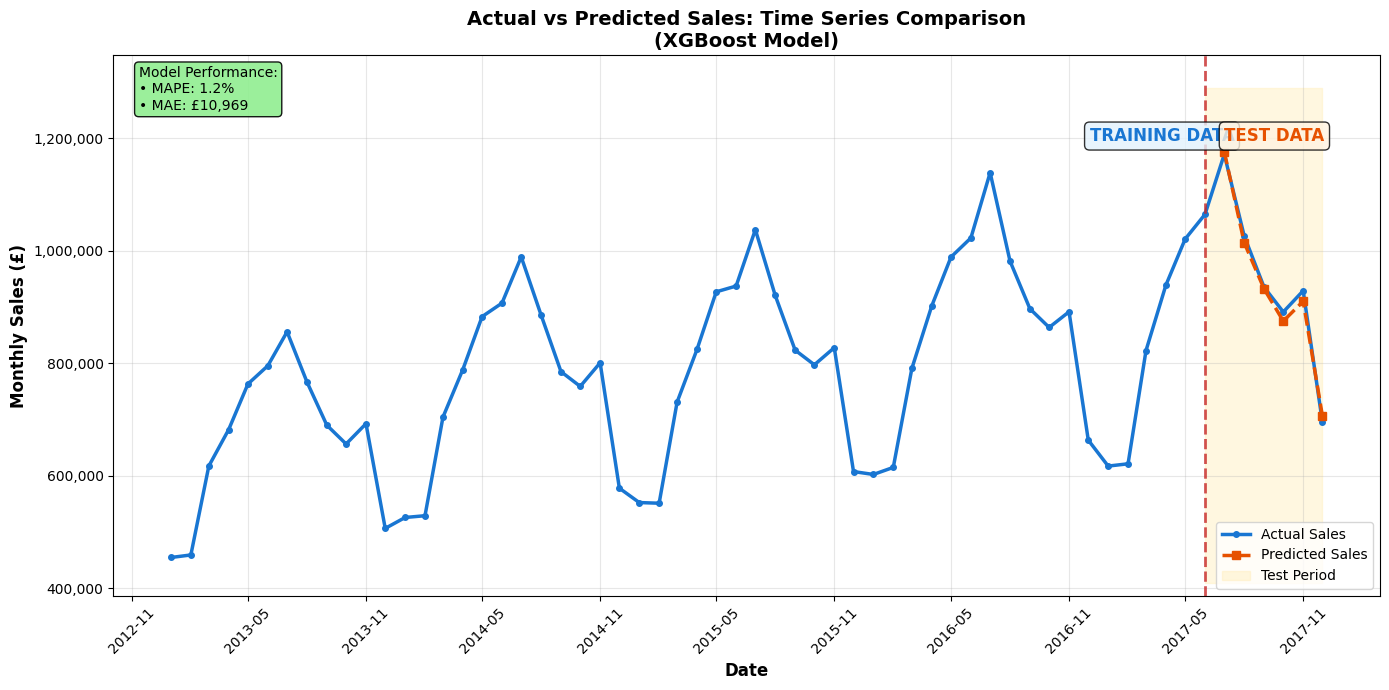


📊 Model Accuracy Metrics:
• Mean Absolute Percentage Error (MAPE): 1.22%
• Mean Absolute Error (MAE): £10,969
• Test Period: 2017-07 to 2017-12


In [95]:
# Plot 11: Actual vs Predicted Sales - Time Series
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Merge predictions with actual data
df_sales_pred = pd.merge(df, df_result, on='date', how='left')

# Create figure
fig, ax = plt.subplots(figsize=(14, 7))

# Plot actual sales (full series)
ax.plot(df_sales_pred['date'], df_sales_pred['sales'], 
        color='#1976D2', linewidth=2.5, label='Actual Sales', marker='o', markersize=4)

# Plot predicted sales (only where we have predictions)
pred_mask = df_sales_pred['pred_value'].notna()
ax.plot(df_sales_pred.loc[pred_mask, 'date'], df_sales_pred.loc[pred_mask, 'pred_value'],
        color='#E65100', linewidth=2.5, label='Predicted Sales', marker='s', markersize=6, linestyle='--')

# Mark train/test split
train_end_date = df_sales_pred[~pred_mask]['date'].iloc[-1]
ax.axvline(x=train_end_date, color='#C62828', linestyle='--', linewidth=2, alpha=0.8)
ax.fill_betweenx([df_sales_pred['sales'].min() * 0.9, df_sales_pred['sales'].max() * 1.1],
                  train_end_date, df_sales_pred['date'].max(),
                  color='#FFECB3', alpha=0.4, label='Test Period')

# Add train/test labels
ax.text(train_end_date - pd.Timedelta(days=180), df_sales_pred['sales'].max() * 1.02, 
        'TRAINING DATA', fontsize=12, fontweight='bold', color='#1976D2',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='#E3F2FD', alpha=0.8))
ax.text(train_end_date + pd.Timedelta(days=30), df_sales_pred['sales'].max() * 1.02,
        'TEST DATA', fontsize=12, fontweight='bold', color='#E65100',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='#FFF3E0', alpha=0.8))

# Calculate and display accuracy metrics
actual_test = df_sales_pred.loc[pred_mask, 'sales'].values
pred_test = df_sales_pred.loc[pred_mask, 'pred_value'].values
mape = np.mean(np.abs((actual_test - pred_test) / actual_test)) * 100
mae = np.mean(np.abs(actual_test - pred_test))

# Add metrics box
metrics_text = f'Model Performance:\n• MAPE: {mape:.1f}%\n• MAE: £{mae:,.0f}'
ax.text(0.02, 0.98, metrics_text, transform=ax.transAxes, fontsize=10,
        verticalalignment='top', bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.9))

# Formatting
ax.set_xlabel('Date', fontsize=12, fontweight='bold')
ax.set_ylabel('Monthly Sales (£)', fontsize=12, fontweight='bold')
ax.set_title('Actual vs Predicted Sales: Time Series Comparison\n(XGBoost Model)', fontsize=14, fontweight='bold')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
plt.xticks(rotation=45)
ax.legend(loc='lower right', fontsize=10)
ax.grid(True, alpha=0.3)
ax.set_ylim(df_sales_pred['sales'].min() * 0.85, df_sales_pred['sales'].max() * 1.15)

# Format y-axis with comma separator
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x:,.0f}'))

plt.tight_layout()
plt.show()

print(f"\n📊 Model Accuracy Metrics:")
print(f"• Mean Absolute Percentage Error (MAPE): {mape:.2f}%")
print(f"• Mean Absolute Error (MAE): £{mae:,.0f}")
print(f"• Test Period: {df_sales_pred.loc[pred_mask, 'date'].min().strftime('%Y-%m')} to {df_sales_pred.loc[pred_mask, 'date'].max().strftime('%Y-%m')}")

### Plot 12: Sales Forecast for Next 3 Months
Forecasted sales with confidence intervals showing predicted peaks and valleys

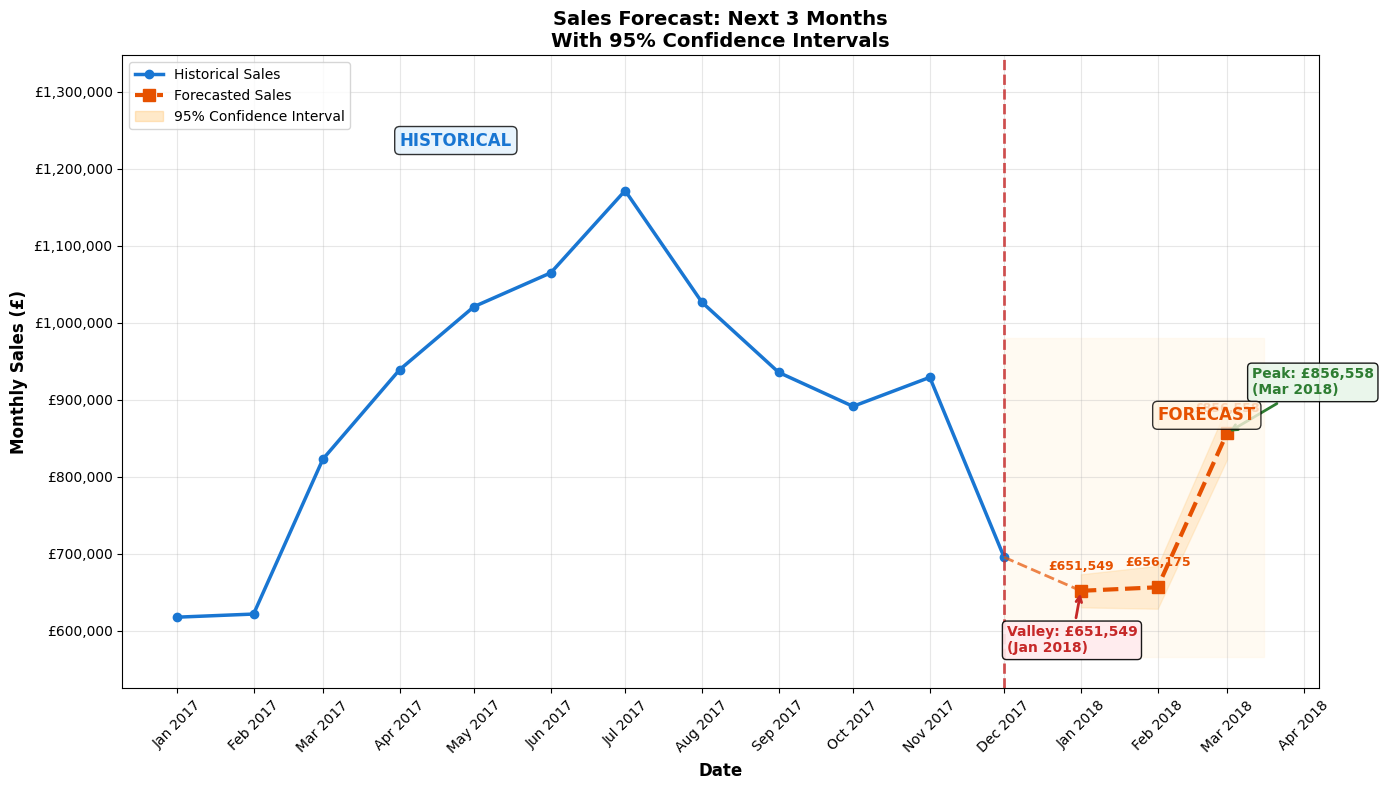


📈 SALES FORECAST SUMMARY - NEXT 3 MONTHS

Forecast Period: January 2018 to March 2018

Month               Forecast   95% CI Lower   95% CI Upper
------------------------------------------------------------
January 2018    £   651,549 £     630,111 £     672,988
February 2018   £   656,175 £     628,305 £     684,046
March 2018      £   856,558 £     822,257 £     890,860

📊 Key Insights:
• Expected Peak: March 2018 (£856,558)
• Expected Valley: January 2018 (£651,549)
• Total 3-Month Forecast: £2,164,283
• Average Monthly Forecast: £721,428


In [96]:
# Plot 12: Sales Forecast for Next 3 Months with Confidence Intervals
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from datetime import timedelta

# Get the last date in our data and create future dates (3 months = ~90 days)
last_date = df['date'].max()
last_sales = df['sales'].iloc[-1]

# Generate future monthly dates
future_dates = pd.date_range(start=last_date + pd.DateOffset(months=1), periods=3, freq='MS')

# Use the model to forecast future values
# We need to create lag features for future predictions
# Get the last 12 diffs for lag features
recent_diffs = list(df_diff['diff'].tail(12).values)

# Forecast next 3 months iteratively
forecast_diffs = []
forecast_sales = []
current_sales = last_sales

for i in range(3):
    # Create feature vector from recent diffs (lag_1 to lag_12)
    features = np.array(recent_diffs[-12:][::-1]).reshape(1, -1)  # Reverse to get lag_1, lag_2, etc.
    
    # Predict the diff
    pred_diff = model.predict(features)[0]
    forecast_diffs.append(pred_diff)
    
    # Calculate forecasted sales
    pred_sales = current_sales + pred_diff
    forecast_sales.append(pred_sales)
    
    # Update for next iteration
    recent_diffs.append(pred_diff)
    current_sales = pred_sales

# Calculate confidence intervals based on model's historical error
residuals = y_pred - y_test
std_error = np.std(residuals)

# Wider confidence intervals for further predictions
ci_multipliers = [1.0, 1.3, 1.6]  # Increasing uncertainty
ci_lower = [fs - 1.96 * std_error * m for fs, m in zip(forecast_sales, ci_multipliers)]
ci_upper = [fs + 1.96 * std_error * m for fs, m in zip(forecast_sales, ci_multipliers)]

# Create DataFrame for forecast
df_forecast = pd.DataFrame({
    'date': future_dates,
    'forecast': forecast_sales,
    'ci_lower': ci_lower,
    'ci_upper': ci_upper
})

# Create the plot
fig, ax = plt.subplots(figsize=(14, 8))

# Plot historical data (last 12 months)
historical_dates = df['date'].tail(12)
historical_sales = df['sales'].tail(12)
ax.plot(historical_dates, historical_sales, 
        color='#1976D2', linewidth=2.5, marker='o', markersize=6, 
        label='Historical Sales')

# Plot forecast
ax.plot(df_forecast['date'], df_forecast['forecast'],
        color='#E65100', linewidth=3, marker='s', markersize=8,
        linestyle='--', label='Forecasted Sales')

# Plot confidence intervals
ax.fill_between(df_forecast['date'], df_forecast['ci_lower'], df_forecast['ci_upper'],
                color='#FFB74D', alpha=0.3, label='95% Confidence Interval')

# Connect historical to forecast
ax.plot([historical_dates.iloc[-1], df_forecast['date'].iloc[0]],
        [historical_sales.iloc[-1], df_forecast['forecast'].iloc[0]],
        color='#E65100', linewidth=2, linestyle='--', alpha=0.7)

# Mark forecast region
ax.axvline(x=last_date, color='#C62828', linestyle='--', linewidth=2, alpha=0.8)
ax.fill_betweenx([min(ci_lower) * 0.9, max(ci_upper) * 1.1],
                  last_date, df_forecast['date'].max() + pd.DateOffset(days=15),
                  color='#FFF3E0', alpha=0.4)

# Add labels for peaks and valleys
max_idx = np.argmax(forecast_sales)
min_idx = np.argmin(forecast_sales)

# Annotate peak
ax.annotate(f'Peak: £{forecast_sales[max_idx]:,.0f}\n({future_dates[max_idx].strftime("%b %Y")})',
            xy=(future_dates[max_idx], forecast_sales[max_idx]),
            xytext=(future_dates[max_idx] + pd.DateOffset(days=10), forecast_sales[max_idx] + 50000),
            fontsize=10, fontweight='bold', color='#2E7D32',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='#E8F5E9', alpha=0.9),
            arrowprops=dict(arrowstyle='->', color='#2E7D32', lw=2))

# Annotate valley
ax.annotate(f'Valley: £{forecast_sales[min_idx]:,.0f}\n({future_dates[min_idx].strftime("%b %Y")})',
            xy=(future_dates[min_idx], forecast_sales[min_idx]),
            xytext=(future_dates[min_idx] - pd.DateOffset(days=30), forecast_sales[min_idx] - 80000),
            fontsize=10, fontweight='bold', color='#C62828',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='#FFEBEE', alpha=0.9),
            arrowprops=dict(arrowstyle='->', color='#C62828', lw=2))

# Add value labels on forecast points
for i, (date, sales, lower, upper) in enumerate(zip(df_forecast['date'], 
                                                      df_forecast['forecast'],
                                                      df_forecast['ci_lower'],
                                                      df_forecast['ci_upper'])):
    ax.annotate(f'£{sales:,.0f}', xy=(date, sales),
                xytext=(0, 15), textcoords='offset points',
                ha='center', fontsize=9, fontweight='bold', color='#E65100')

# Add section labels
ax.text(historical_dates.iloc[3], max(historical_sales) * 1.05,
        'HISTORICAL', fontsize=12, fontweight='bold', color='#1976D2',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='#E3F2FD', alpha=0.8))
ax.text(future_dates[1], max(ci_upper) * 0.98,
        'FORECAST', fontsize=12, fontweight='bold', color='#E65100',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='#FFF3E0', alpha=0.8))

# Formatting
ax.set_xlabel('Date', fontsize=12, fontweight='bold')
ax.set_ylabel('Monthly Sales (£)', fontsize=12, fontweight='bold')
ax.set_title('Sales Forecast: Next 3 Months\nWith 95% Confidence Intervals', fontsize=14, fontweight='bold')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.xaxis.set_major_locator(mdates.MonthLocator())
plt.xticks(rotation=45)
ax.legend(loc='upper left', fontsize=10)
ax.grid(True, alpha=0.3)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'£{x:,.0f}'))

# Set y-limits with some padding
y_min = min(min(historical_sales), min(ci_lower)) * 0.85
y_max = max(max(historical_sales), max(ci_upper)) * 1.15
ax.set_ylim(y_min, y_max)

plt.tight_layout()
plt.show()

# Print forecast summary
print("\n" + "="*60)
print("📈 SALES FORECAST SUMMARY - NEXT 3 MONTHS")
print("="*60)
print(f"\nForecast Period: {future_dates[0].strftime('%B %Y')} to {future_dates[-1].strftime('%B %Y')}")
print(f"\n{'Month':<15} {'Forecast':>12} {'95% CI Lower':>14} {'95% CI Upper':>14}")
print("-"*60)
for date, sales, lower, upper in zip(future_dates, forecast_sales, ci_lower, ci_upper):
    print(f"{date.strftime('%B %Y'):<15} £{sales:>10,.0f} £{lower:>12,.0f} £{upper:>12,.0f}")

print(f"\n📊 Key Insights:")
print(f"• Expected Peak: {future_dates[max_idx].strftime('%B %Y')} (£{forecast_sales[max_idx]:,.0f})")
print(f"• Expected Valley: {future_dates[min_idx].strftime('%B %Y')} (£{forecast_sales[min_idx]:,.0f})")
total_forecast = sum(forecast_sales)
print(f"• Total 3-Month Forecast: £{total_forecast:,.0f}")
avg_forecast = total_forecast / 3
print(f"• Average Monthly Forecast: £{avg_forecast:,.0f}")

### Day-of-Week Sales Analysis
Understanding which days drive the most sales

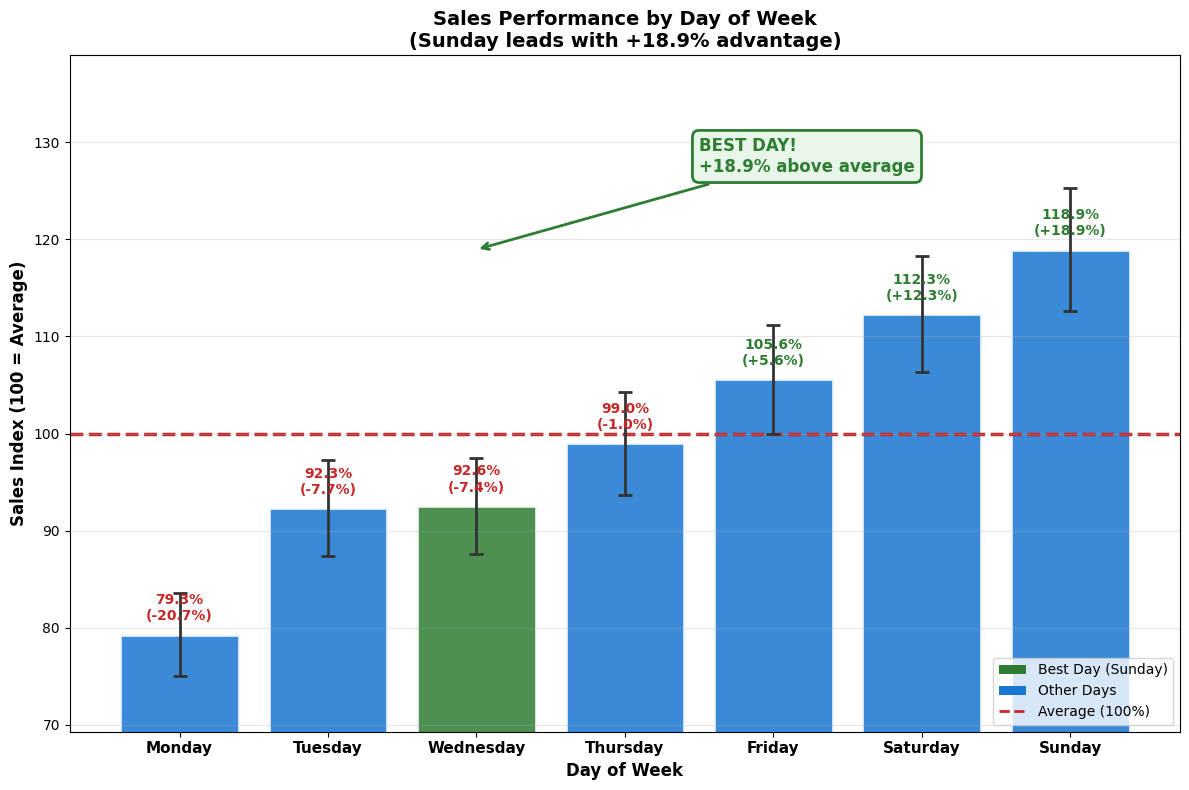


📊 Day-of-Week Sales Analysis:
• Best performing day: Sunday (+18.9% above average)
• Lowest performing day: Monday (-20.7% vs average)
• Average daily sales: £52

📈 Day-by-Day Breakdown:
  Monday   : 79.3% (-20.7%)
  Tuesday  : 92.3% (-7.7%)
  Wednesday: 92.6% (-7.4%)
  Thursday : 99.0% (-1.0%)
  Friday   : 105.6% (+5.6%)
  Saturday : 112.3% (+12.3%)
  Sunday   : 118.9% (+18.9%)


In [97]:
# Re-load original data to analyze by day of week
df_daily = pd.read_csv("../datasets/sales_prediction_train.csv")
df_daily['date'] = pd.to_datetime(df_daily['date'])
df_daily['day_of_week'] = df_daily['date'].dt.day_name()
df_daily['day_num'] = df_daily['date'].dt.dayofweek

# Calculate average daily sales by day of week
day_sales = df_daily.groupby(['day_of_week', 'day_num']).agg({
    'sales': ['mean', 'std', 'sum', 'count']
}).reset_index()
day_sales.columns = ['Day', 'DayNum', 'AvgSales', 'StdSales', 'TotalSales', 'Count']
day_sales = day_sales.sort_values('DayNum')

# Calculate normalized index (100 = average)
overall_avg = day_sales['AvgSales'].mean()
day_sales['SalesIndex'] = (day_sales['AvgSales'] / overall_avg) * 100
day_sales['PctDiff'] = day_sales['SalesIndex'] - 100

# Find the best performing day
best_day = day_sales.loc[day_sales['SalesIndex'].idxmax()]
best_day_name = best_day['Day']
best_day_pct = best_day['PctDiff']

# Create bar chart
fig, ax = plt.subplots(figsize=(12, 8))

# Define colors - highlight the best day
colors = ['#1976D2'] * 7  # Default blue
best_idx = day_sales[day_sales['Day'] == best_day_name].index[0] - day_sales.index[0]
colors[best_idx] = '#2E7D32'  # Green for best day

# Create bars
bars = ax.bar(range(7), day_sales['SalesIndex'], 
              color=colors, edgecolor='white', linewidth=2, alpha=0.85)

# Add error bars (standard deviation scaled to index)
error_scaled = (day_sales['StdSales'] / overall_avg) * 100
ax.errorbar(range(7), day_sales['SalesIndex'], yerr=error_scaled * 0.1, 
            fmt='none', color='#333', capsize=5, capthick=2, linewidth=2)

# Add horizontal line at 100 (average)
ax.axhline(y=100, color='#C62828', linestyle='--', linewidth=2.5, 
           label='Average (100%)', zorder=1)

# Add value labels on bars
for i, (bar, pct_diff) in enumerate(zip(bars, day_sales['PctDiff'])):
    height = bar.get_height()
    sign = '+' if pct_diff > 0 else ''
    color = '#2E7D32' if pct_diff > 0 else '#C62828'
    ax.annotate(f'{height:.1f}%\n({sign}{pct_diff:.1f}%)', 
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 8), textcoords="offset points", 
                ha='center', va='bottom', fontsize=10, fontweight='bold', color=color)

# Highlight annotation for best day
ax.annotate(f'BEST DAY!\n+{best_day_pct:.1f}% above average',
            xy=(best_idx, day_sales['SalesIndex'].max()),
            xytext=(best_idx + 1.5, day_sales['SalesIndex'].max() + 8),
            fontsize=12, fontweight='bold', color='#2E7D32',
            bbox=dict(boxstyle='round,pad=0.4', facecolor='#E8F5E9', edgecolor='#2E7D32', linewidth=2),
            arrowprops=dict(arrowstyle='->', color='#2E7D32', lw=2))

# Styling
ax.set_xticks(range(7))
ax.set_xticklabels(day_sales['Day'], fontsize=11, fontweight='bold')
ax.set_xlabel('Day of Week', fontsize=12, fontweight='bold')
ax.set_ylabel('Sales Index (100 = Average)', fontsize=12, fontweight='bold')
ax.set_title(f'Sales Performance by Day of Week\n({best_day_name} leads with +{best_day_pct:.1f}% advantage)', 
             fontsize=14, fontweight='bold')
ax.set_ylim(min(day_sales['SalesIndex']) - 10, max(day_sales['SalesIndex']) + 20)
ax.legend(loc='lower right', fontsize=11)
ax.grid(True, alpha=0.3, axis='y')

# Add legend for colors
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#2E7D32', label=f'Best Day ({best_day_name})'),
    Patch(facecolor='#1976D2', label='Other Days'),
    plt.Line2D([0], [0], color='#C62828', linestyle='--', linewidth=2, label='Average (100%)')
]
ax.legend(handles=legend_elements, loc='lower right', fontsize=10)

plt.tight_layout()
plt.savefig('day_of_week_sales.png', dpi=150, bbox_inches='tight')
plt.show()

# Print insights
print(f"\n📊 Day-of-Week Sales Analysis:")
print(f"• Best performing day: {best_day_name} (+{best_day_pct:.1f}% above average)")
worst_day = day_sales.loc[day_sales['SalesIndex'].idxmin()]
print(f"• Lowest performing day: {worst_day['Day']} ({worst_day['PctDiff']:.1f}% vs average)")
print(f"• Average daily sales: £{overall_avg:,.0f}")
print(f"\n📈 Day-by-Day Breakdown:")
for _, row in day_sales.iterrows():
    sign = '+' if row['PctDiff'] > 0 else ''
    print(f"  {row['Day']:9s}: {row['SalesIndex']:.1f}% ({sign}{row['PctDiff']:.1f}%)")